In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

biden_df = pd.read_csv('translated_data/biden_translated.csv')
trump_df = pd.read_csv('translated_data/trump_translated.csv')
voter_df = pd.read_csv('data/processed/voter_reg_individual_response_subset.csv')


In [ ]:
voter_2020 = voter_df[voter_df['year'] == 2020].copy()

race_map = {
    100: 'White',
    200: 'Black',
    300: 'American Indian',
    651: 'Asian',
    652: 'Hawaiian/Pacific Islander',
    800: 'Two or More Races'
}

voter_2020['race_label'] = voter_2020['race'].map(race_map)

# CPS registration indicator (0/1); group mean × 100 = registration rate %
registration_pct_by_demo = (
    voter_2020.groupby(['state', 'race_label', 'gender'])['voter_registration']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'voter_registration': 'registration_rate_pct'})
)

registration_pct_by_demo.head()

/var/folders/rj/_c2qxh155cx0zbl6n49s95kr0000gn/T/ipykernel_54486/428586646.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  voter_2020['race_label'] = voter_2020['race'].map(race_map)


,state,race_label,gender,voter_registration
0,Alabama,American Indian,Female,0.000000
1,Alabama,American Indian,Male,33.333333
2,Alabama,Asian,Female,100.000000
3,Alabama,Black,Female,44.827586
4,Alabama,Black,Male,26.470588


In [ ]:
us_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 
    'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 
    'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 
    'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 
    'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 
    'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 
    'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 
    'West Virginia', 'Wisconsin', 'Wyoming'
]

biden_df = biden_df[biden_df['state'].isin(us_states)]
trump_df = trump_df[trump_df['state'].isin(us_states)]

# Aggregate Biden Data
biden_stats = biden_df.groupby('state').agg(
    biden_vol=('tweet', 'count'),
    biden_sent=('sentiment_score', lambda x: x.abs().mean())
)

# Aggregate Trump Data
trump_stats = trump_df.groupby('state').agg(
    trump_vol=('tweet', 'count'),
    trump_sent=('sentiment_score', lambda x: x.abs().mean())
)

# state-Level Dataframe
state_social_media = biden_stats.join(trump_stats, how='outer').fillna(0)
state_social_media['total_vol'] = state_social_media['biden_vol'] + state_social_media['trump_vol']

state_social_media = state_social_media.reset_index()
state_social_media.head()

,state,biden_vol,biden_sent,trump_vol,trump_sent,total_vol
0,Alabama,864,0.513427,849,0.561014,1713
1,Alaska,429,0.544362,311,0.530311,740
2,Arizona,3248,0.528633,2865,0.574899,6113
3,Arkansas,469,0.528749,613,0.535736,1082
4,California,25817,0.492110,31149,0.599987,56966


In [ ]:

state_voter_stats = voter_2020.groupby('state').agg(
    actual_reg_rate=('voter_registration', 'mean'),
    sample_size=('voter_registration', 'count') 
)


state_voter_stats = state_voter_stats.reset_index()
state_voter_stats.head()

,state,actual_reg_rate,sample_size
0,Alabama,0.438944,303
1,Alaska,0.506329,158
2,Arizona,0.263682,201
3,Arkansas,0.349673,306
4,California,0.242278,1036


In [ ]:
final_regression_df = pd.merge(state_social_media, state_voter_stats, on='state', how='inner')

if final_regression_df['actual_reg_rate'].max() <= 1.0:
    final_regression_df['actual_reg_rate'] = final_regression_df['actual_reg_rate'] * 100

final_regression_df.head()

,state,biden_vol,biden_sent,trump_vol,trump_sent,total_vol,actual_reg_rate,sample_size
0,Alabama,864,0.513427,849,0.561014,1713,43.894389,303
1,Alaska,429,0.544362,311,0.530311,740,50.632911,158
2,Arizona,3248,0.528633,2865,0.574899,6113,26.368159,201
3,Arkansas,469,0.528749,613,0.535736,1082,34.967320,306
4,California,25817,0.492110,31149,0.599987,56966,24.227799,1036


In [ ]:
import statsmodels.api as sm

X = final_regression_df[['biden_vol', 'biden_sent', 'trump_vol', 'trump_sent']]
y = final_regression_df['actual_reg_rate']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        actual_reg_rate   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.7983
Date:                Sun, 10 May 2026   Prob (F-statistic):              0.533
Time:                        14:12:26   Log-Likelihood:                -175.09
No. Observations:                  50   AIC:                             360.2
Df Residuals:                      45   BIC:                             369.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3888     25.986      0.477      0.6

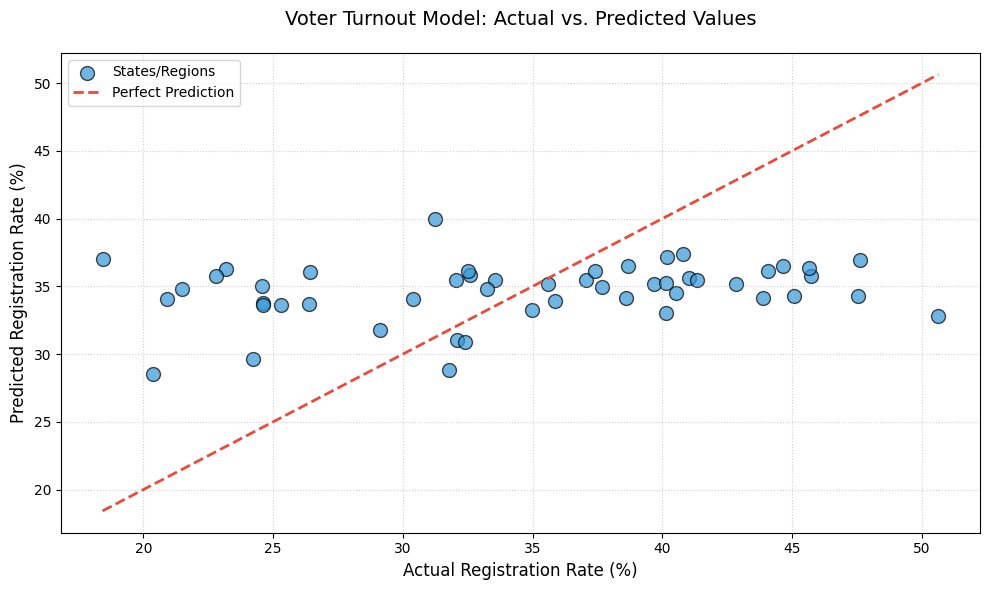

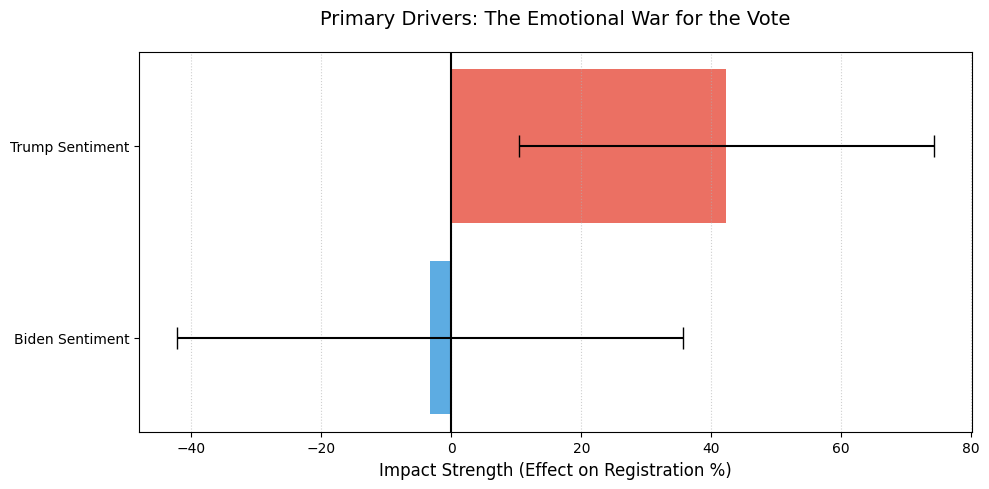

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(y, predictions, color='#3498db', alpha=0.7, edgecolors='k', s=100, label='States/Regions')

line_coords = [min(y.min(), predictions.min()), max(y.max(), predictions.max())]
plt.plot(line_coords, line_coords, color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Registration Rate (%)', fontsize=12)
plt.ylabel('Predicted Registration Rate (%)', fontsize=12)
plt.title('Voter Turnout Model: Actual vs. Predicted Values', fontsize=14, pad=20)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')

# bar plot
sent_params = model.params.filter(like='sent')
sent_errors = model.bse.filter(like='sent')
sent_labels = ['Biden Sentiment', 'Trump Sentiment']

plt.figure(figsize=(10, 5))

colors = ['#3498db', '#e74c3c'] 

plt.barh(sent_labels, sent_params, xerr=sent_errors, color=colors, alpha=0.8, capsize=8)
plt.axvline(0, color='black', linestyle='-', linewidth=1.5)

plt.xlabel('Impact Strength (Effect on Registration %)', fontsize=12)
plt.title('Primary Drivers: The Emotional War for the Vote', fontsize=14, pad=20)
plt.grid(axis='x', linestyle=':', alpha=0.6)


plt.tight_layout()
plt.savefig('sentiment_impact_refined.png')
plt.show()

plt.show()

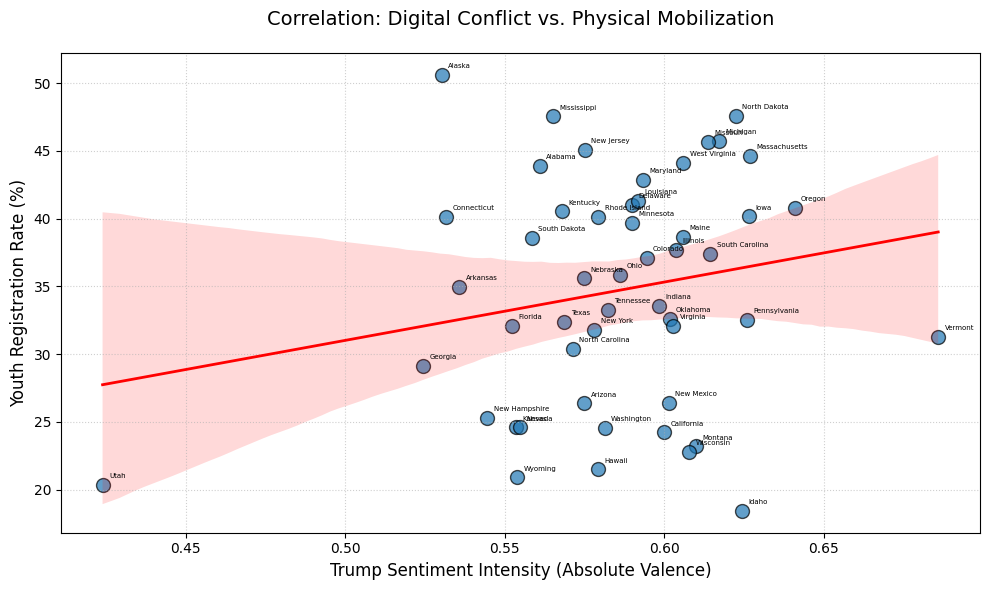

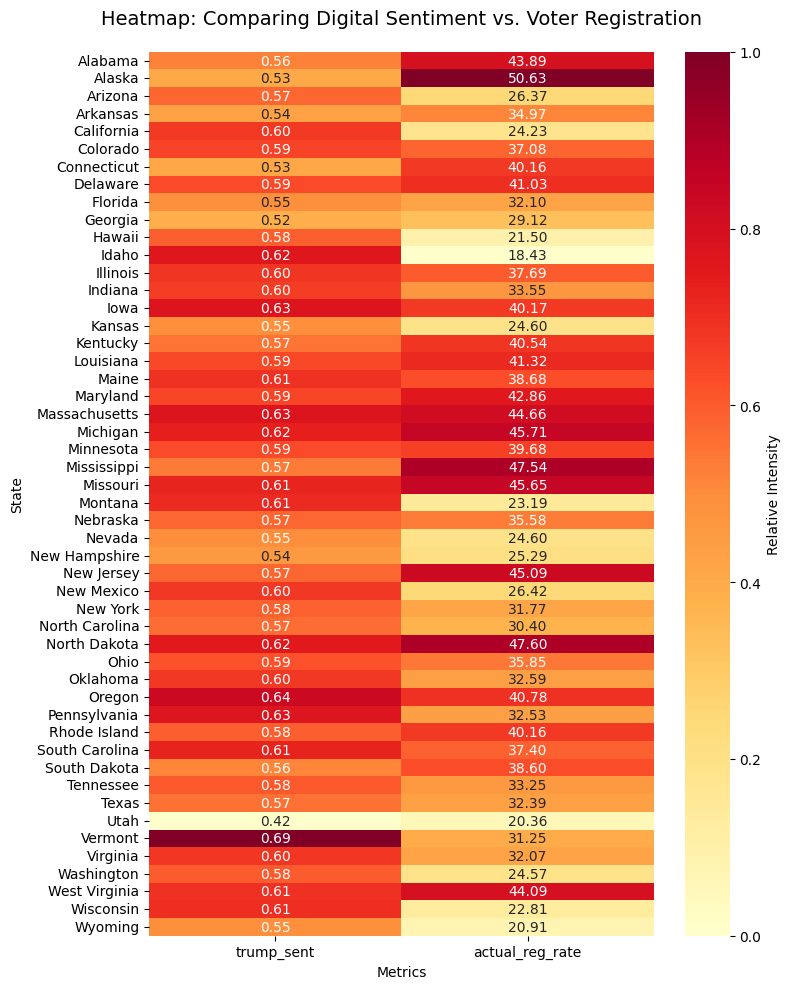

In [ ]:
# correlation
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='trump_sent', y='actual_reg_rate', data=final_regression_df, 
            scatter_kws={'s':100, 'alpha':0.7, 'edgecolor':'black'}, 
            line_kws={'color':'red', 'lw':2})

for i, row in final_regression_df.iterrows():
    plt.text(row['trump_sent']+0.002, row['actual_reg_rate']+0.5, row['state'], fontsize=5)

plt.xlabel('Trump Sentiment Intensity (Absolute Valence)', fontsize=12)
plt.ylabel('Youth Registration Rate (%)', fontsize=12)
plt.title('Correlation: Digital Conflict vs. Physical Mobilization', fontsize=14, pad=20)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('scatter.png')
plt.show()

# heatmap
heatmap_data = final_regression_df.set_index('state')[['trump_sent', 'actual_reg_rate']]
heatmap_data_scaled = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data_scaled, annot=heatmap_data, cmap='YlOrRd', fmt='.2f', cbar_kws={'label': 'Relative Intensity'})
plt.title('Heatmap: Comparing Digital Sentiment vs. Voter Registration', fontsize=14, pad=20)
plt.xlabel('Metrics')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('state_heatmap.png')
plt.show()